# MDE Map: 仮説起票前の検出可能性ゲート

## tl;dr

9ホールについて、`games_normalized >= 1000` の台に条件づけたMDEと検出可能性を計算する。  
異なる推定器のMDE生値は比較せず、事前固定した実測参照効果量で割った `detectability` だけを比較する。  
このNotebookは法則探索を行わず、どの窓・指標・粒度なら典型的な既知効果を検出できるかだけを示す。

## Context & Methods

### Key Assumptions

- MDEは `2.8 × 日次効果SD / sqrt(W)` の正規近似。
- 末尾・section・machine_name・corner1は台属性なので position 参照クラスとして扱う。
- dd_event・strong_zorome・weekdayは日付属性なので calendar 参照クラスとして扱う。
- `rb_rate` と `bonus_rate` は JUG・BT・bonus_judgeable のみに適用する。
- `payout_within_model` は、各ホールの全対象期間かつ1000G以上の行における機種平均をpayoutから引く。
- 台属性の複数グループ軸では、各グループの日次SDを並べた中央グループを代表系列にする。
- 日付軸はセグメント内日次平均の「群内平均 − 群外平均」を二群差として扱い、Wは対象群日数で数える。
- 主表は暦28・56・180・365日。日付軸は `eff_n = base_rate × calendar_days` とし、`eff_n < 5` なら `INSUFFICIENT_DATA` とする。
- bootstrapは台属性軸では代表系列を、日付軸では対象群と群外を別々に7日ブロックで再標本化する。

入力は `db/` 配下の指定9DB。`pachinko.db` と `pachinko_data.db` は利用しない。

In [1]:
from pathlib import Path
import importlib.util
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

CURRENT_DIR = Path.cwd().resolve()
ROOT = next(
    path for path in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (path / "CLAUDE.md").exists() and (path / "backtest").exists()
)
MODULE_PATH = ROOT / "backtest" / "scratch" / "mde_map_analysis.py"
spec = importlib.util.spec_from_file_location("mde_map_analysis", MODULE_PATH)
mde = importlib.util.module_from_spec(spec)
assert spec.loader is not None
sys.modules[spec.name] = mde
spec.loader.exec_module(mde)

plt.rcParams.update({
    "font.family": "Yu Gothic",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#4b5563",
    "axes.labelcolor": "#1f2937",
    "text.color": "#1f2937",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "axes.grid": True,
    "grid.color": "#e5e7eb",
    "grid.linewidth": 0.8,
})
CHART_DIR = ROOT / "output" / "jupyter-notebook"
CHART_DIR.mkdir(parents=True, exist_ok=True)

## Data

### 1. 検収後、9ホールを再計算

In [2]:
results, acceptance, sources = mde.run_full_analysis()
display(acceptance.round(6))
display(sources)

[OK] weekend flag coverage verified:
             hall          period  n_days  weekend_rate date_min date_max  passed
            楽園蒲田店 before_20260601     515      0.287379 20250101 20260531    True
            楽園蒲田店   from_20260601     102      0.274510 20260601 20260912    True
マルハンメガシティ2000-蒲田7 before_20260601     327      0.281346 20250707 20260530    True
マルハンメガシティ2000-蒲田7   from_20260601      97      0.268041 20260601 20260912    True
マルハンメガシティ2000-蒲田1 before_20260601     502      0.286853 20250101 20260531    True
マルハンメガシティ2000-蒲田1   from_20260601     101      0.277228 20260601 20260912    True
          みとや大森町店 before_20260601     514      0.284047 20250101 20260529    True
          みとや大森町店   from_20260601     100      0.280000 20260601 20260912    True
         ARROW池上店 before_20260601     514      0.287938 20250101 20260531    True
         ARROW池上店   from_20260601      63      0.253968 20260601 20260910    True
           ヒロキ東口店 before_20260601     514      0.285992 20250

[OK] 楽園蒲田店: rows=243707, dates=20250101..20260912


[OK] マルハンメガシティ2000-蒲田7: rows=280398, dates=20250707..20260912


[OK] マルハンメガシティ2000-蒲田1: rows=186943, dates=20250101..20260912


[OK] みとや大森町店: rows=138751, dates=20250101..20260912


...

[OK] レイトギャップ平和島: rows=177943, dates=20250320..20260912


[OK] ザ-シティ-ベルシティ雑色店: rows=57363, dates=20250101..20260912


[OK] 金時京急蒲田店: rows=65061, dates=20250101..20260912
[OK] physical-axis 28-day DETECTABLE cells=32
[OK] matched physical estimator cells=312
          estimator  matched_cells  median_ratio_vs_payout  mean_ratio_vs_payout  win_rate_vs_payout
         bonus_rate            312                1.203943              1.259164            0.987179
            rb_rate            312                0.827007              0.868845            0.192308
payout_within_model            312                1.000216              1.000502            0.641026


,metric,expected,actual,tolerance,passed
0,mean_effect,0.131,0.130617,0.01,True
1,daily_sd,3.757,3.756597,0.01,True
2,n_days,613.000,613.000000,0.00,True
3,mde_7,3.976,3.975608,0.01,True
4,mde_14,2.811,2.811180,0.01,True
5,mde_28,1.988,1.987804,0.01,True
6,mde_56,1.406,1.405590,0.01,True
7,mde_180,0.784,0.784001,0.01,True


,hall,db_path,rows_games_ge_1000,date_min,date_max,n_dates,layout_missing,master_missing,daily_summary_flag_missing,any_event_days,strong_zorome_days,weekend_rate_before_20260601,weekend_rate_from_20260601
0,楽園蒲田店,db\楽園蒲田店.db,243707,20250101,20260912,615,471,0,0,226,21,0.287379,0.274510
1,マルハンメガシティ2000-蒲田7,db\マルハンメガシティ2000-蒲田7.db,280398,20250707,20260912,424,0,0,0,209,15,0.281346,0.268041
2,マルハンメガシティ2000-蒲田1,db\マルハンメガシティ2000-蒲田1.db,186943,20250101,20260912,603,10212,0,0,286,21,0.286853,0.277228
3,みとや大森町店,db\みとや大森町店.db,138751,20250101,20260912,614,316,0,0,288,21,0.284047,0.280000
4,ARROW池上店,db\ARROW池上店.db,171698,20250101,20260910,577,171698,0,0,250,19,0.287938,0.253968
5,ヒロキ東口店,db\ヒロキ東口店.db,108617,20250101,20260912,611,108617,0,0,242,21,0.285992,0.288660
6,レイトギャップ平和島,db\レイトギャップ平和島.db,177943,20250320,20260912,535,177943,0,0,211,18,0.288991,0.272727
7,ザ-シティ-ベルシティ雑色店,db\ザ-シティ-ベルシティ雑色店.db,57363,20250101,20260912,615,57363,0,0,280,21,0.287379,0.270000
8,金時京急蒲田店,db\金時京急蒲田店.db,65061,20250101,20260912,618,65061,0,0,252,21,0.285992,0.278846


In [3]:
assert len(results) == 9 * 5 * 7 * 4 * 4
assert results.duplicated(["hall", "segment", "contrast", "estimator", "calendar_days"]).sum() == 0
assert acceptance["passed"].all()
assert len(results.loc[
    results["calendar_days"].eq(28)
    & results["contrast"].isin(mde.PHYSICAL_CONTRASTS)
    & results["gate"].eq("DETECTABLE")
]) == 32

gate_counts = results["gate"].value_counts(dropna=False).rename_axis("gate").reset_index(name="rows")
display(gate_counts)

,gate,rows
0,DETECTABLE,1710
1,INSUFFICIENT_DATA,1072
2,NOT_APPLICABLE,1008
3,MARGINAL,936
4,UNDETECTABLE,314


## Results

### 2. 楽園の検収MDE曲線

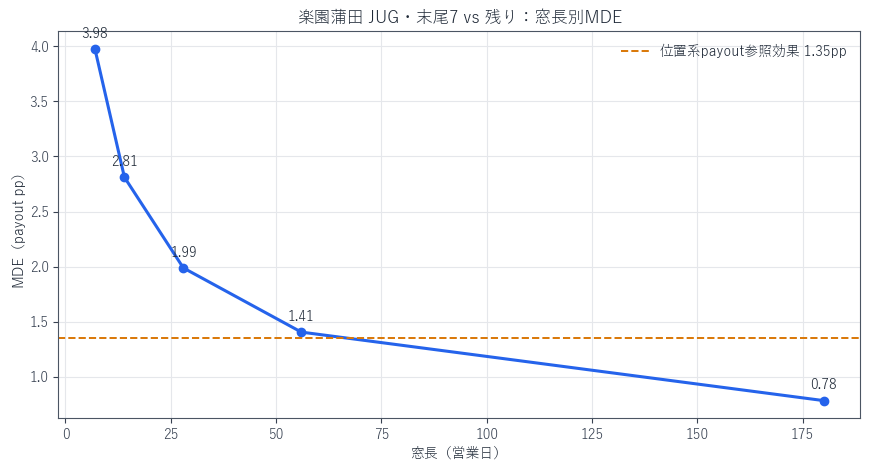

In [4]:
acceptance_sd = float(acceptance.loc[acceptance["metric"].eq("daily_sd"), "actual"].iloc[0])
acceptance_curve = pd.DataFrame({
    "window_days": mde.ACCEPTANCE_WINDOWS,
    "mde_pp": [2.8 * acceptance_sd / math.sqrt(window) for window in mde.ACCEPTANCE_WINDOWS],
})

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.plot(acceptance_curve["window_days"], acceptance_curve["mde_pp"], marker="o", color="#2563eb", linewidth=2.2)
for row in acceptance_curve.itertuples(index=False):
    ax.annotate(f"{row.mde_pp:.2f}", (row.window_days, row.mde_pp), xytext=(0, 8), textcoords="offset points", ha="center")
ax.axhline(1.35, color="#d97706", linestyle="--", linewidth=1.4, label="位置系payout参照効果 1.35pp")
ax.set_title("楽園蒲田 JUG・末尾7 vs 残り：窓長別MDE")
ax.set_xlabel("窓長（営業日）")
ax.set_ylabel("MDE（payout pp）")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(CHART_DIR / "mde_map_acceptance.png", dpi=160, bbox_inches="tight")
plt.show()

### 3. ホール別の推定器detectability

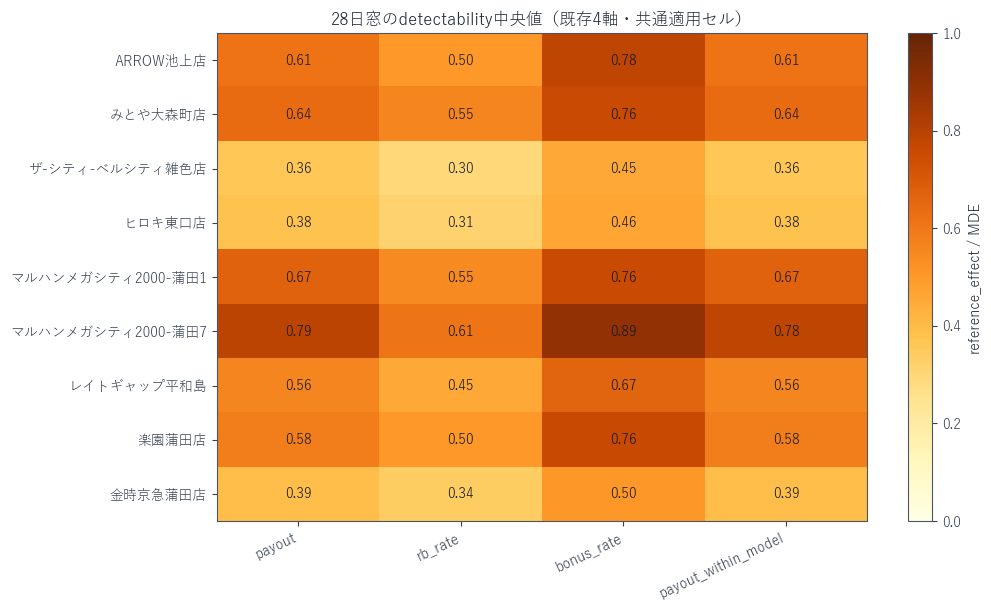

estimator,payout,rb_rate,bonus_rate,payout_within_model
hall,,,,
ARROW池上店,0.614,0.499,0.778,0.614
みとや大森町店,0.638,0.555,0.755,0.638
ザ-シティ-ベルシティ雑色店,0.360,0.296,0.451,0.361
ヒロキ東口店,0.377,0.314,0.464,0.377
マルハンメガシティ2000-蒲田1,0.670,0.545,0.758,0.670
マルハンメガシティ2000-蒲田7,0.785,0.607,0.888,0.783
レイトギャップ平和島,0.562,0.451,0.667,0.562
楽園蒲田店,0.579,0.497,0.759,0.580
金時京急蒲田店,0.394,0.337,0.501,0.394


In [5]:
common_28 = results.loc[
    results["calendar_days"].eq(28)
    & results["contrast"].isin(mde.PHYSICAL_CONTRASTS)
    & results["segment"].isin(["JUG", "BT", "bonus_judgeable"])
    & results["gate"].isin(["DETECTABLE", "MARGINAL", "UNDETECTABLE"])
].copy()

heat = common_28.pivot_table(
    index="hall", columns="estimator", values="detectability", aggfunc="median"
).reindex(columns=list(mde.ESTIMATORS))

fig, ax = plt.subplots(figsize=(10.5, 6.2))
image = ax.imshow(heat.to_numpy(), aspect="auto", cmap="YlOrBr", vmin=0, vmax=max(1.0, float(np.nanmax(heat.to_numpy()))))
ax.set_xticks(range(len(heat.columns)), heat.columns, rotation=25, ha="right")
ax.set_yticks(range(len(heat.index)), heat.index)
for row_index in range(len(heat.index)):
    for column_index in range(len(heat.columns)):
        value = heat.iloc[row_index, column_index]
        if np.isfinite(value):
            ax.text(column_index, row_index, f"{value:.2f}", ha="center", va="center", color="#111827")
ax.set_title("28日窓のdetectability中央値（既存4軸・共通適用セル）")
ax.grid(False)
fig.colorbar(image, ax=ax, label="reference_effect / MDE")
fig.tight_layout()
fig.savefig(CHART_DIR / "mde_map_estimator_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

display(heat.round(3))

### 4. 窓長を伸ばした場合のdetectability

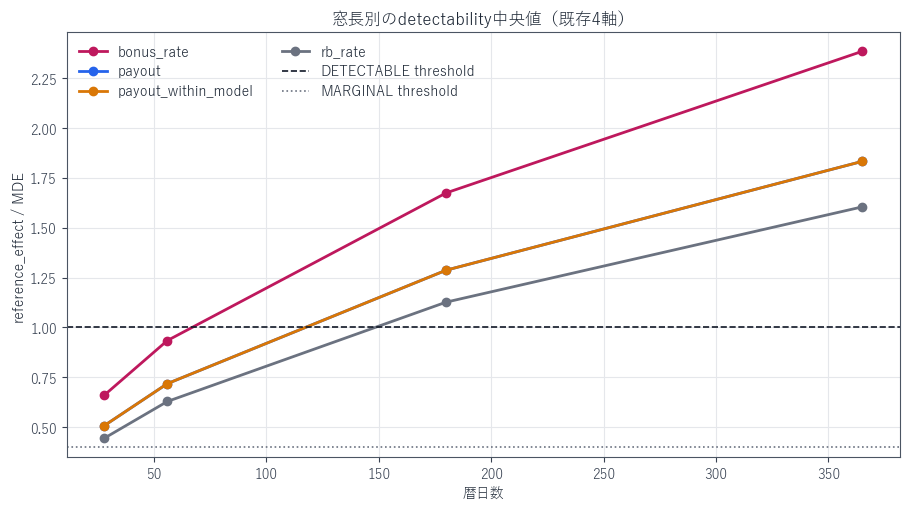

,calendar_days,estimator,median_detectability
0,28,bonus_rate,0.660
1,28,payout,0.508
2,28,payout_within_model,0.508
3,28,rb_rate,0.444
4,56,bonus_rate,0.934
5,56,payout,0.718
6,56,payout_within_model,0.718
7,56,rb_rate,0.628
8,180,bonus_rate,1.675
9,180,payout,1.287


In [6]:
common_cells = results.loc[
    results["contrast"].isin(mde.PHYSICAL_CONTRASTS)
    & results["segment"].isin(["JUG", "BT", "bonus_judgeable"])
    & results["gate"].isin(["DETECTABLE", "MARGINAL", "UNDETECTABLE"])
]
window_summary = (
    common_cells.groupby(["calendar_days", "estimator"], observed=True)["detectability"]
    .median()
    .rename("median_detectability")
    .reset_index()
)

palette = {
    "payout": "#2563eb",
    "payout_within_model": "#d97706",
    "rb_rate": "#6b7280",
    "bonus_rate": "#be185d",
}
fig, ax = plt.subplots(figsize=(9.2, 5.2))
for estimator, part in window_summary.groupby("estimator", observed=True):
    ax.plot(part["calendar_days"], part["median_detectability"], marker="o", linewidth=2, label=estimator, color=palette[estimator])
ax.axhline(1.0, color="#111827", linestyle="--", linewidth=1.2, label="DETECTABLE threshold")
ax.axhline(0.4, color="#6b7280", linestyle=":", linewidth=1.2, label="MARGINAL threshold")
ax.set_title("窓長別のdetectability中央値（既存4軸）")
ax.set_xlabel("暦日数")
ax.set_ylabel("reference_effect / MDE")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(CHART_DIR / "mde_map_window_curve.png", dpi=160, bbox_inches="tight")
plt.show()

display(window_summary.round(3))

### 5. 暦日グリッドのゲート状況

In [7]:
physical_gate_28 = (
    results.loc[
        results["calendar_days"].eq(28)
        & results["contrast"].isin(mde.PHYSICAL_CONTRASTS)
    ]
    .groupby(["contrast", "gate"], observed=True)
    .size()
    .unstack(fill_value=0)
)
display(physical_gate_28)

calendar_gate = (
    results.loc[
        results["contrast"].isin(mde.CALENDAR_CONTRASTS)
    ]
    .groupby(["contrast", "calendar_days", "gate"], observed=True)
    .size()
    .unstack(fill_value=0)
)
display(calendar_gate)

physical_detectable_28 = int(
    results.loc[
        results["calendar_days"].eq(28)
        & results["contrast"].isin(mde.PHYSICAL_CONTRASTS)
        & results["gate"].eq("DETECTABLE")
    ].shape[0]
)
print(f"暦28日の位置系DETECTABLEセル: {physical_detectable_28}")

gate,DETECTABLE,INSUFFICIENT_DATA,MARGINAL,NOT_APPLICABLE,UNDETECTABLE
contrast,,,,,
corner1,23,80,30,36,11
last_digit,8,0,88,36,48
machine_name,0,0,63,36,81
section,1,80,35,36,28


gate                         DETECTABLE  INSUFFICIENT_DATA  MARGINAL  \
contrast      calendar_days                                            
dd_event      28                     93                  0        42   
              56                    114                  0        30   
              180                   138                  0         6   
              365                   144                  0         0   
strong_zorome 28                      0                144         0   
              56                      0                144         0   
              180                    57                  0        76   
              365                    93                  0        51   
weekday       28                      0                144         0   
              56                     93                  0        42   
              180                   130                  0        14   
              365                   136                  0         8   

gate                         NOT_APPLICABLE  UNDETECTABLE  
contrast      calendar_days                                
dd_event      28                         36             9  
              56                         36             0  
              180                        36             0  
              365                        36             0  
strong_zorome 28                         36             0  
              56                         36             0  
              180                        36            11  
              365                        36             0  
weekday       28                         36             0  
              56                         36             9  
              180                        36             0  
              365                        36             0

暦28日の位置系DETECTABLEセル: 32


## Takeaways

In [8]:
ratio_summary, matched_cell_count = mde.physical_estimator_ratio_summary(results)
ratio_summary = ratio_summary.set_index("estimator")
bonus_ratio = float(ratio_summary.loc["bonus_rate", "median_ratio_vs_payout"])
bonus_win = 100.0 * float(ratio_summary.loc["bonus_rate", "win_rate_vs_payout"])
rb_ratio = float(ratio_summary.loc["rb_rate", "median_ratio_vs_payout"])
rb_win = 100.0 * float(ratio_summary.loc["rb_rate", "win_rate_vs_payout"])
within_ratio = float(ratio_summary.loc["payout_within_model", "median_ratio_vs_payout"])
missing_layout_halls = sources.loc[sources["layout_missing"].eq(sources["rows_games_ge_1000"]), "hall"].tolist()

summary_text = "\n".join([
    "- 検収は全項目一致。検収fixtureは2026-09-10截止、全体マップは各DBの最新日まで使用した。",
    f"- 暦28日の位置系DETECTABLEは **{physical_detectable_28}** 件。日付系とは合算しない。",
    f"- 既存4軸の対応{matched_cell_count}セルでは bonus_rate/payout のdetectability中央値比は **{bonus_ratio:.3f}**（勝率 {bonus_win:.1f}%）、rb_rateは **{rb_ratio:.3f}**（勝率 {rb_win:.1f}%）。末尾の参照修正前の値は使わない。",
    f"- payout_within_model/payoutの中央値比 **{within_ratio:.3f}** は想定どおり。これは分散削減ではなく機種構成バイアス除去のために使う。",
    "- 窓2倍の1.414倍はMDE式の恒等式であり実測発見ではない。指標変更と窓延長は乗算的だが、後者は法則の定常性を仮定する。",
    "- 日付軸は暦日ごとのeff_nで評価し、位置系とDETECTABLE件数を合算しない。",
    f"- レイアウト履歴が全行欠落しているホール: **{', '.join(missing_layout_halls) if missing_layout_halls else 'なし'}**。これらのsection・corner1はINSUFFICIENT_DATA。",
    "- この結果は法則の存在を示さず、典型的な事前固定効果を検出できる測定条件だけを示す。",
])
display(Markdown(summary_text))

- 検収は全項目一致。検収fixtureは2026-09-10截止、全体マップは各DBの最新日まで使用した。
- 暦28日の位置系DETECTABLEは **32** 件。日付系とは合算しない。
- 既存4軸の対応312セルでは bonus_rate/payout のdetectability中央値比は **1.204**（勝率 98.7%）、rb_rateは **0.827**（勝率 19.2%）。末尾の参照修正前の値は使わない。
- payout_within_model/payoutの中央値比 **1.000** は想定どおり。これは分散削減ではなく機種構成バイアス除去のために使う。
- 窓2倍の1.414倍はMDE式の恒等式であり実測発見ではない。指標変更と窓延長は乗算的だが、後者は法則の定常性を仮定する。
- 日付軸は暦日ごとのeff_nで評価し、位置系とDETECTABLE件数を合算しない。
- レイアウト履歴が全行欠落しているホール: **ARROW池上店, ヒロキ東口店, レイトギャップ平和島, ザ-シティ-ベルシティ雑色店, 金時京急蒲田店**。これらのsection・corner1はINSUFFICIENT_DATA。
- この結果は法則の存在を示さず、典型的な事前固定効果を検出できる測定条件だけを示す。

### 計算していないこと・近似

- 新しい法則、相関、投入パターンは探索していない。
- レジーム分割、ルール探索、パラメータ探索、walk-forward再実装は行っていない。
- MDEは正規近似で、bootstrapは代表系列を使った実測CI半幅。
- 日付軸のMDEは対象群と群外の両方の分散を含む二群差として計算した。
- dd_eventは祝日・週末・X日の和集合であり、ホール固有イベントDDではない。weekdayと重なるため独立証拠として合算しない。
- MDEの生値は異なる単位間で比較していない。
- 位置系参照値は末尾を含む台属性4軸、暦系参照値はdd_event・strong_zorome・weekdayだけに適用した。
- 参照効果量は `backtest/results/deathwatch/status.csv` に基づくユーザー指定中央値を固定値として使用した。